In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Lab 9 - Multi-layer Perceptron Forward Pass & Backpropagation

## Part I
For this exercise you will implement a simple 2-layer perceptron with the forward pass and the backpropagation to learn the weights

For the first part you'll build and train a 2-layer neural network that predicts the prices of houses, using the usual Boston housing dataset.

In [4]:
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
boston = pd.read_table("housing.txt", names=housing_names, sep=r'\s+')

As usual, consider the MEDV as your target variable. 
* Split the data into training, validation and testing (70,15,15)%
* Experiment with different number of neurons per layer for your network, using the validation set

In [100]:
# your code goes here
y = boston.values[:,-1]
X = boston.values[:,:-1]

# Normalizar os dados
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3, random_state=12)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5, random_state=12)

### Funções complementares

In [130]:
def sigmoid_activation(z):
    # your code goes here
    return 1/(1 + np.exp(-z))

def add_bias(X:np.ndarray):
    return np.c_[X, np.ones((X.shape[0], 1))]

def MSE(Y_true: np.ndarray, Y_pred: np.ndarray):
    return np.mean((Y_true - Y_pred)**2)

## Forward Pass, para antes da inicialização e para depois da inicialização

In [102]:
# your code goes here
def initialize_two_layer_perceptron(X: np.ndarray, act_hidden, dim_input, dim_hidden, dim_output, act_output=None):
    """
    Implements the forward pass of a two-layer fully connected perceptron.
    
    Parameters
    ----------
    X : a 2-dimensional array
        the input data
    act_hidden : function
        the activation function to be used for the hidden layer
    act_output : function
        the activation function to be used for the output layet
    dim_input : int
        the dimensionality of the input layer
    dim_hidden : int
        the dimensionality of the hidden layer
    dim_output : int
        the dimensionality of the output layer
    Returns
    -------
    y_pred : float
        the output of the computation of the forward pass of the network
    """

    # hidden layer
    X_bb = add_bias(X) # bb = by bias
    W1 = np.random.randn(dim_hidden, dim_input + 1) * 0.01 # plus 1 for bias
    A1 = act_hidden(X_bb.dot(W1.T))

    # saida
    A1_bb = add_bias(A1)
    W2 = np.random.randn(dim_output, dim_hidden + 1) * 0.01
    Z2 = A1_bb.dot(W2.T) 

    if act_output != None:
        A2 = act_output(Z2)
        return W1, A1, W2, A2 # W, A and Z matrix

    return  W1, A1, W2, Z2 # W, A and Z matrix

def forward_pass_two_layers(X: np.ndarray, act_hidden, W1, W2, act_output=None):
    """
    Parameters
    ----------

    X: a 2-dimensional array
        the input data without bias
    W1, W2: a 2-dimensional array
        the weights for layer 1 and layer 2, by bias
    """

    X_bb = add_bias(X)
    A1 = act_hidden(X_bb.dot(W1.T))

    A1_bb = add_bias(A1)
    Z2 = A1_bb.dot(W2.T)

    if act_output is not None:
        A2 = act_output(Z2)
        return A1, A2

    return A1, Z2
    
    

## ALgoritmo de Backpropagation
- Duas layers
- Com função de activação sigmoide para as hidden layers 

In [ ]:
def backpropagation_GD(X, Y_true, act_hidden, dim_input, dim_hidden, dim_output, lr, max_epoch):
    
    # 1. INITIALIZE FORWARD PROPAGATION
    W1, A1, W2, Y_pred = initialize_two_layer_perceptron(
        X,
        act_hidden,
        dim_input,
        dim_hidden,
        dim_output
    )

    n = X.shape[0]
    X_bb = add_bias(X)


    for k in range(max_epoch):
        A1_bb = add_bias(A1)

        # 2. BACKPROPAGATION
        dla_2 = 2*(Y_pred - Y_true)

        # ignorando a coluna do bias
        dla_1 = dla_2.dot(W2[:,:-1]) * A1 * (1 - A1)

        # 3. CALCULO DO GRADIENTE DE CADA MATRIZ W

        dEdW_2 = ((dla_2.T).dot(A1_bb))/n
        dEdW_1 = ((dla_1.T).dot(X_bb))/n

        # ATE AQUI O BACK PROPAGATION 

        W1 = W1 - lr*dEdW_1
        W2 = W2 - lr*dEdW_2

        # 4. FORWARD PASS
        A1, Y_pred = forward_pass_two_layers(
            X,
            act_hidden,
            W1,
            W2
        )

    return W1, W2


## Teste do algoritmo de backpropagation

In [ ]:
W1_o, W2_o = backpropagation_GD(
    X_train,
    y_train[:,None],
    sigmoid_activation,
    X_train.shape[1],
    20,
    1,
    0.1,
    8000)

_, Y_val_pred = forward_pass_two_layers(X_val, sigmoid_activation, W1_o, W2_o)
_, Y_train_pred = forward_pass_two_layers(X_train, sigmoid_activation, W1_o, W2_o)

print(MSE(Y_pred=Y_val_pred, Y_true=y_val))
print(MSE(Y_pred=Y_train_pred, Y_true=y_train))

## Testar para varios valores na hidden layer

In [151]:
dims = range(5, 55)
err_val = []

for k in dims:
    W1_o, W2_o = backpropagation_GD(
    X_train,
    y_train[:,None],
    sigmoid_activation,
    X_train.shape[1],
    k,
    1,
    0.1,
    4000)

    _, Y_val_pred = forward_pass_two_layers(X_val, sigmoid_activation, W1_o, W2_o)
    err = MSE(y_val, Y_val_pred)

    err_val.append(err)

Text(0.5, 1.0, 'Erro da rede neural usando o algoritmo de Backpropagation no conjunto de validação')

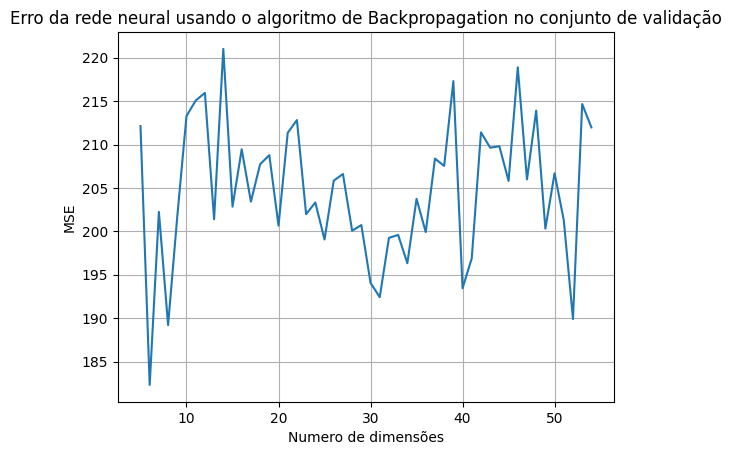

In [152]:
plt.plot(dims, err_val)
plt.grid()
plt.xlabel("Numero de dimensões")
plt.ylabel("MSE")
plt.title("Erro da rede neural usando o algoritmo de Backpropagation no conjunto de validação")

## Part II 

For this exercise you will build and train a 2-layer neural network that predicts the exact digit from a hand-written image, using the MNIST dataset. 
For this exercise, add weight decay to your network.

In [2]:
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

In [4]:
X = digits.data
y = digits.target

In [5]:
X.shape

(1797, 64)

Again, you will split the data into training, validation and testing.

In [ ]:
# your code goes here:

In [ ]:
# your code goes here:
